In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('/content/StudentsPerformance.csv')

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.isnull().sum()
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,1,1,1,1,72,72,74
1,0,2,4,1,0,69,90,88
2,0,1,3,1,1,90,95,93
3,1,0,0,0,1,47,57,44
4,1,2,4,1,1,76,78,75


In [5]:
X = df.drop('math score', axis=1)

y = df['math score']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [8]:
lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

lr_r2 = r2_score(
    y_test,
    lr_pred
)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R2:", lr_r2)

Linear Regression RMSE: 5.317450940660133
Linear Regression R2: 0.8838026201112223


In [9]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [10]:
dt_rmse = np.sqrt(
    mean_squared_error(y_test, dt_pred)
)

dt_r2 = r2_score(
    y_test,
    dt_pred
)

print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree R2:", dt_r2)

Decision Tree RMSE: 7.801281945936834
Decision Tree R2: 0.7498956186117769


In [11]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [12]:
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest RMSE: 6.065824068029948
Random Forest R2: 0.8487940184356789


In [13]:
results = pd.DataFrame({

    'Model':[
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'RMSE':[
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],

    'R2 Score':[
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,5.317451,0.883803
1,Decision Tree,7.801282,0.749896
2,Random Forest,6.065824,0.848794


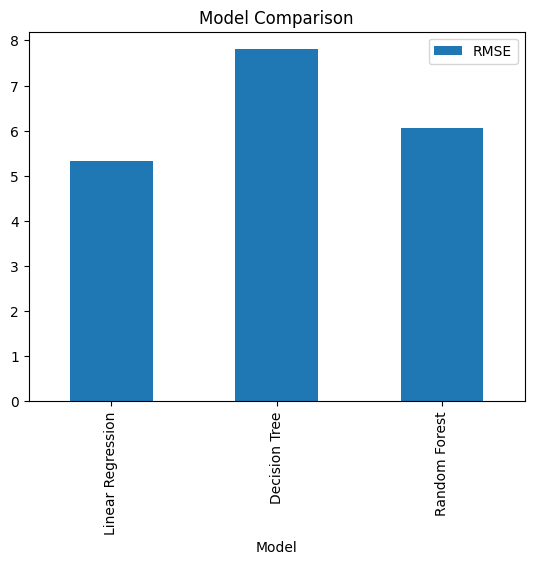

In [14]:
import matplotlib.pyplot as plt

results.plot(
    x='Model',
    y='RMSE',
    kind='bar'
)

plt.title("Model Comparison")

plt.show()